In [1]:
import numpy as np             #1.1
import pandas as pd
from seaborn import scatterplot
from unicodedata import category

df=pd.read_csv("catalog_products.xlsx - Sheet1 (1).csv")
print("первые 5 строк:\n",df.head(5))
print("всего строк и столбцов:\n",df.shape)
print("типы данных всех колонок\n",df.dtypes)
print("количество пропусков в каждой колонке:\n",df.isnull().sum())
"""Полезными признаками для предсказания цены могут быть:

brand — бренд товара (известные бренды обычно дороже)
category — категория товара
rating — рейтинг товара
reviews — количество отзывов
discount — размер скидки
availability — наличие на складе
specifications — характеристики товара

Эти признаки могут влиять на цену и поэтому полезны для построения модели."""

первые 5 строк:
     col_1  col_2  col_3        col_4  col_5  col_6     col_7  col_8  col_9  \
0    Home    762    303  Electronics     49    348  Clothing    206    123   
1  Sports    190     34       Sports    107     99  Clothing    836    775   
2   Books    711      2         Home     93    876      Home    868     69   
3  Sports    484    362        Books    636    361      Home    897    111   
4  Sports    733    195         Home    829    937  Clothing    428    871   

        col_10  ...  col_41  col_42    col_43  col_44  col_45       col_46  \
0       Sports  ...     676     471      Home     511     424  Electronics   
1  Electronics  ...     700     696     Books     329     677  Electronics   
2        Books  ...     418     596      Home     781     622  Electronics   
3     Clothing  ...     620     357      Home     811     240     Clothing   
4         Home  ...     740     845  Clothing     272     143  Electronics   

   col_47  col_48       col_49  col_50  
0   

'Полезными признаками для предсказания цены могут быть:\n\nbrand — бренд товара (известные бренды обычно дороже)\ncategory — категория товара\nrating — рейтинг товара\nreviews — количество отзывов\ndiscount — размер скидки\navailability — наличие на складе\nspecifications — характеристики товара\n\nЭти признаки могут влиять на цену и поэтому полезны для построения модели.'

In [2]:
numeric_cols=df.select_dtypes(include=[np.number]).columns       #1.2

df[numeric_cols]=df[numeric_cols].astype(float)
df[numeric_cols]=df[numeric_cols].fillna(df[numeric_cols].mean())
print(df[numeric_cols].isna().sum())

col_2     0
col_3     0
col_5     0
col_6     0
col_8     0
col_9     0
col_11    0
col_12    0
col_14    0
col_15    0
col_17    0
col_18    0
col_20    0
col_21    0
col_23    0
col_24    0
col_26    0
col_27    0
col_29    0
col_30    0
col_32    0
col_33    0
col_35    0
col_36    0
col_38    0
col_39    0
col_41    0
col_42    0
col_44    0
col_45    0
col_47    0
col_48    0
col_50    0
dtype: int64


In [3]:
df["total_value"]=df["col_2"]*df["col_3"]              #1.3
df["log_price"]=np.log(df["col_2"])
df["double_stock"]=df["col_3"]*2
print(df)

         col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
0         Home  762.0  303.0  Electronics   49.0  348.0     Clothing  206.0   
1       Sports  190.0   34.0       Sports  107.0   99.0     Clothing  836.0   
2        Books  711.0    2.0         Home   93.0  876.0         Home  868.0   
3       Sports  484.0  362.0        Books  636.0  361.0         Home  897.0   
4       Sports  733.0  195.0         Home  829.0  937.0     Clothing  428.0   
...        ...    ...    ...          ...    ...    ...          ...    ...   
9995  Clothing  444.0  107.0         Home  429.0    1.0        Books   71.0   
9996     Books  434.0  857.0  Electronics  831.0  437.0       Sports  764.0   
9997  Clothing  228.0  937.0        Books  648.0  686.0  Electronics  847.0   
9998      Home  509.0  291.0       Sports  666.0  250.0     Clothing  231.0   
9999     Books  799.0  349.0        Books  294.0  410.0        Books  524.0   

      col_9       col_10  ...  col_44  col_45      

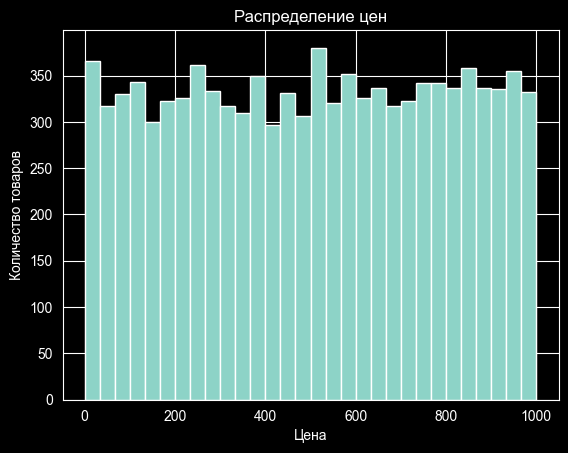

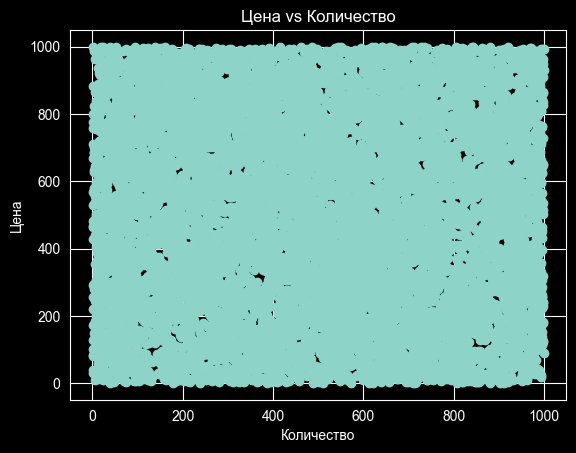

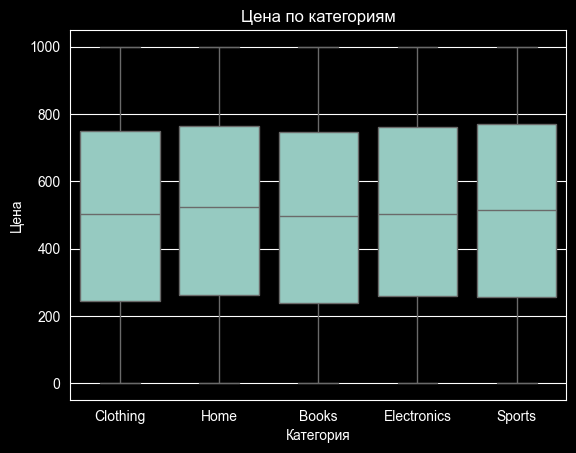

In [4]:
import matplotlib.pyplot as plt             #1.4
import seaborn as sns
plt.hist(df["col_2"],bins=30)
plt.xlabel("Цена")
plt.ylabel("Количество товаров")
plt.title("Распределение цен")
plt.show()

plt.scatter(df["col_3"], df["col_2"])
plt.xlabel("Количество")
plt.ylabel("Цена")
plt.title("Цена vs Количество")
plt.show()

sns.boxplot(x="col_7",y="col_2",data=df)
plt.xlabel("Категория")
plt.ylabel("Цена")
plt.title("Цена по категориям")
plt.show()

In [5]:
mean_price=df["col_2"].mean()          #1.5
std_price=df["col_2"].std()
anomalies=df[(df["col_2"]>mean_price+3*std_price) | (df["col_2"]<mean_price-3*std_price)].copy()
print(anomalies)
df_clean = df.drop(anomalies.index)


Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, log_price, double_stock]
Index: []

[0 rows x 53 columns]


In [6]:
from sklearn.preprocessing import LabelEncoder    #1.6
le=LabelEncoder()
df['col_7']=le.fit_transform(df["col_7"])
print(df)

         col_1  col_2  col_3        col_4  col_5  col_6  col_7  col_8  col_9  \
0         Home  762.0  303.0  Electronics   49.0  348.0      1  206.0  123.0   
1       Sports  190.0   34.0       Sports  107.0   99.0      1  836.0  775.0   
2        Books  711.0    2.0         Home   93.0  876.0      3  868.0   69.0   
3       Sports  484.0  362.0        Books  636.0  361.0      3  897.0  111.0   
4       Sports  733.0  195.0         Home  829.0  937.0      1  428.0  871.0   
...        ...    ...    ...          ...    ...    ...    ...    ...    ...   
9995  Clothing  444.0  107.0         Home  429.0    1.0      0   71.0  466.0   
9996     Books  434.0  857.0  Electronics  831.0  437.0      4  764.0  269.0   
9997  Clothing  228.0  937.0        Books  648.0  686.0      2  847.0   72.0   
9998      Home  509.0  291.0       Sports  666.0  250.0      1  231.0  947.0   
9999     Books  799.0  349.0        Books  294.0  410.0      0  524.0  303.0   

           col_10  ...  col_44  col_45 

In [7]:
from sklearn.model_selection import train_test_split         #1.7
y=df["col_2"]
X = df[["col_3"]]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
from sklearn.linear_model import LinearRegression       #1.8
from sklearn.metrics import mean_absolute_error, mean_squared_error
model = LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
print(f"Средняя ошибка (MAE): {mae:.2f}")
print(f"Квадратичная ошибка (MSE): {mse:.2f}")

Средняя ошибка (MAE): 248.54
Квадратичная ошибка (MSE): 82536.70


In [9]:
from sklearn.linear_model import LinearRegression           #1.9
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error

y=df["col_2"]
X=df[["total_value", "double_stock", "log_price","col_7"]]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

print(f"Средняя ошибка (MAE): {mae:.2f}")
print(f"Квадратичная ошибка (MSE): {mse:.2f}")

Средняя ошибка (MAE): 78.86
Квадратичная ошибка (MSE): 11124.27


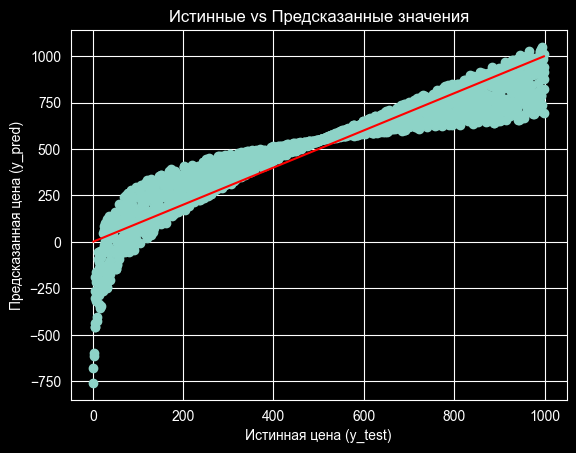

In [10]:
plt.scatter(y_test, y_pred)     #1.10

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="red")

plt.xlabel("Истинная цена (y_test)")
plt.ylabel("Предсказанная цена (y_pred)")
plt.title("Истинные vs Предсказанные значения")

plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler   #1.11
scaler=StandardScaler()
cols=["col_3", "total_value", "double_stock", "log_price"]
df[cols]=scaler.fit_transform(df[cols])
print(df[cols].mean())
print(df[cols].std())

col_3          -1.456613e-17
total_value    -1.563194e-17
double_stock   -1.456613e-17
log_price       2.236433e-16
dtype: float64
col_3           1.00005
total_value     1.00005
double_stock    1.00005
log_price       1.00005
dtype: float64


col_3           0.000000e+00
total_value     3.246256e-09
double_stock    2.222979e-09
log_price       1.000000e+00
dtype: float64


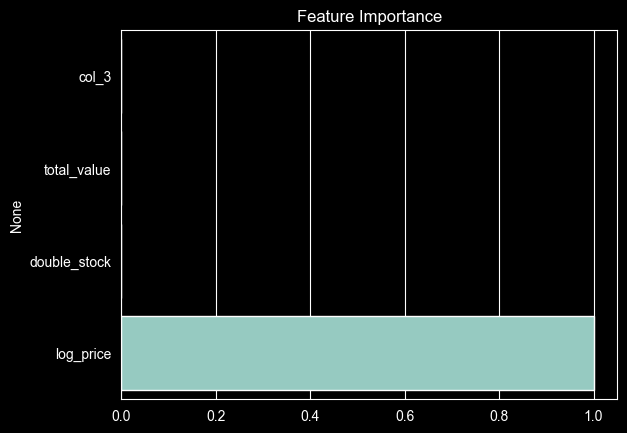

In [12]:
from sklearn.tree import DecisionTreeRegressor        #1.12
from sklearn.model_selection import train_test_split

y=df['col_2']
X=df[["col_3","total_value","double_stock","log_price"]]

X_train,X_test,y_train,t_test=train_test_split(X,y,test_size=0.2,random_state=42)

model=DecisionTreeRegressor()
model.fit(X_train,y_train)

importance=pd.Series(
model.feature_importances_,
index=X.columns
)

print(importance)

sns.barplot(x=importance.values,y=importance.index)
plt.title("Feature Importance")
plt.show()

In [13]:
from sklearn.preprocessing import PolynomialFeatures            #1.13
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error

poly=PolynomialFeatures(degree=2)

X_poly=poly.fit_transform(X)

X_train,X_test,y_train,y_test=train_test_split(X_poly,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

mae=mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 15.272968458788782
MSE: 481.71661267051286


In [14]:
from sklearn.neighbors import KNeighborsRegressor               #1.14
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = KNeighborsRegressor(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)

MAE: 4.1032
MSE: 30.597159999999995


In [15]:
from sklearn.linear_model import LinearRegression         #1.15
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

results={}
categories=df["col_7"].unique()
for x in categories:
    category_df=df[df["col_7"]==x]
    if len(category_df) < 5:
        continue

    X=category_df[["col_3"]]
    y=category_df['col_2']

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

    model=LinearRegression()
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)
    mae=mean_absolute_error(y_pred,y_test)

    results[x]=mae
print("MAE по категориям (чем меньше число, тем точнее модель):")
for x,y in results.items():
    print(f"{x}: {y:.2f}")

MAE по категориям (чем меньше число, тем точнее модель):
1: 258.86
3: 245.52
0: 255.32
2: 249.56
4: 247.24


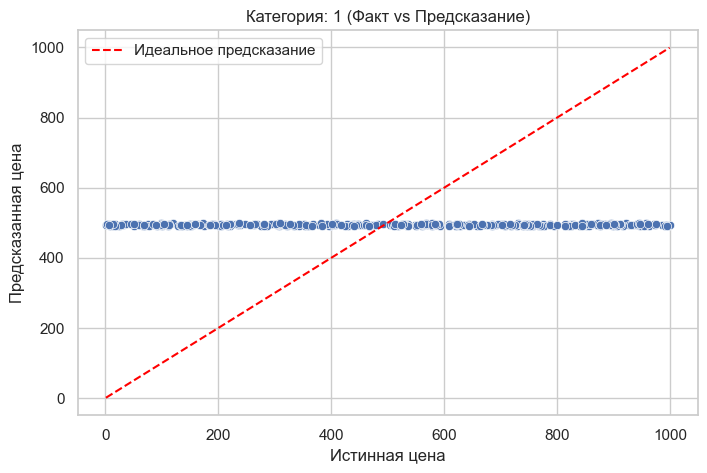

--- Топ ошибок для 1 ---
      Actual   Predicted   Abs_Error
9117   999.0  493.874228  505.125772
6173   996.0  491.412893  504.587107
3061   994.0  491.892374  502.107626




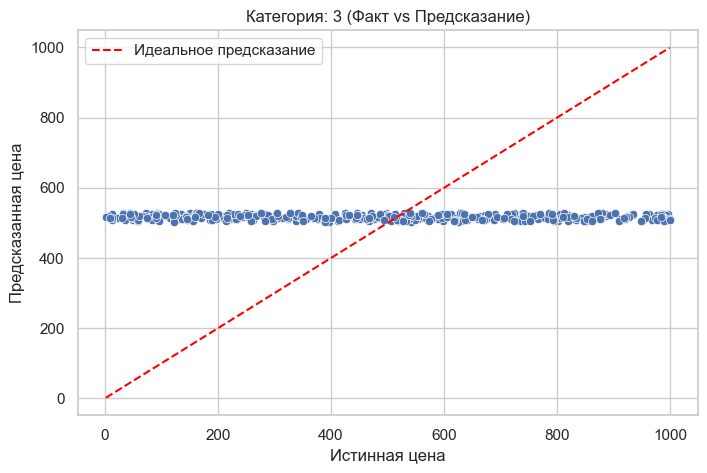

--- Топ ошибок для 3 ---
      Actual   Predicted   Abs_Error
2961     4.0  520.253049  516.253049
8613     2.0  516.482099  514.482099
1595     6.0  520.149023  514.149023




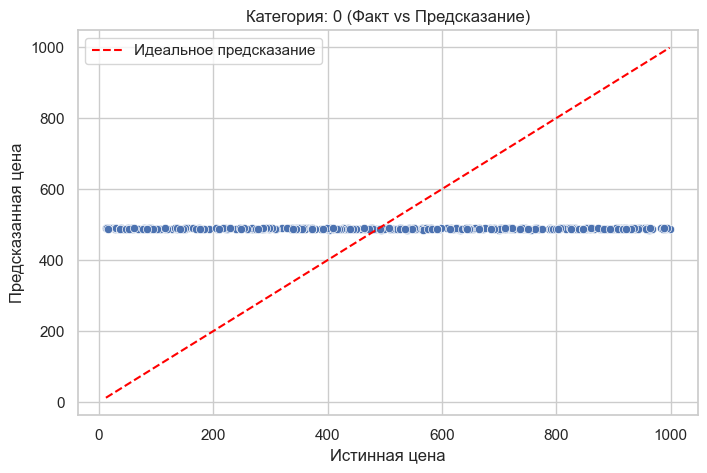

--- Топ ошибок для 0 ---
      Actual   Predicted   Abs_Error
1860   998.0  488.612191  509.387809
4065   993.0  489.302169  503.697831
6657   990.0  487.512537  502.487463




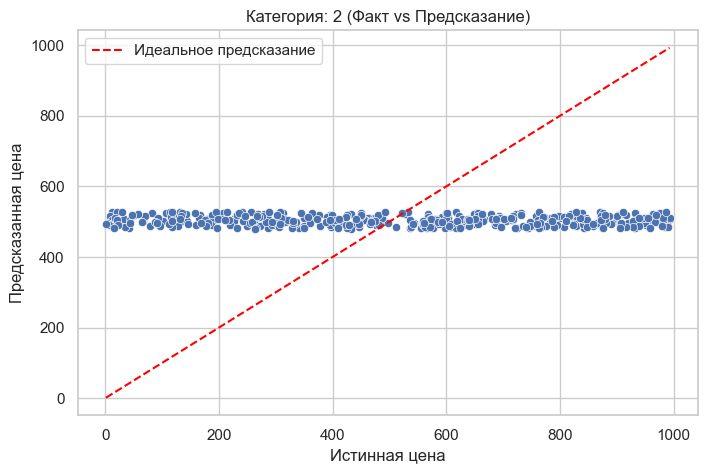

--- Топ ошибок для 2 ---
      Actual   Predicted   Abs_Error
184     12.0  527.941675  515.941675
4611     9.0  516.429358  507.429358
8804    20.0  526.442172  506.442172




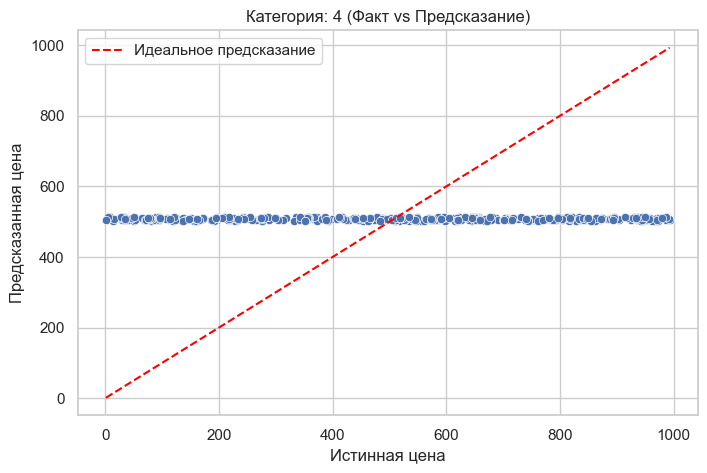

--- Топ ошибок для 4 ---
      Actual   Predicted   Abs_Error
8538     5.0  512.214312  507.214312
7198     1.0  505.516203  504.516203
3223     9.0  512.752270  503.752270




In [16]:
sns.set_theme(style="whitegrid")        #1.16
for x in categories:
    category_df=df[df["col_7"]==x]
    if len(category_df) < 10:
        continue

    X=category_df[["col_3"]]
    y=category_df['col_2']

    X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

    model=LinearRegression()
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test, y=y_pred)

    max_val=max(y_test.max(),y_pred.max())
    min_val = min(y_test.min(), y_pred.min())

    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Идеальное предсказание')
    plt.title(f"Категория: {x} (Факт vs Предсказание)")
    plt.xlabel("Истинная цена")
    plt.ylabel("Предсказанная цена")
    plt.legend()
    plt.show()

    errors = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred,
        'Abs_Error': np.abs(y_test - y_pred)
    })
    print(f"--- Топ ошибок для {x} ---")
    print(errors.sort_values(by='Abs_Error', ascending=False).head(3))
    print("\n")

In [17]:
from sklearn.model_selection import cross_val_score           #1.17
from sklearn.linear_model import LinearRegression
X = df[['col_3', 'total_value', 'double_stock', 'log_price']]
y = df['col_2']

model=LinearRegression()
mae_scores=cross_val_score(model,X,y,cv=5,scoring="neg_mean_absolute_error")
mse_scores=cross_val_score(model,X,y,cv=5,scoring="neg_mean_squared_error")

mae_scores = -mae_scores
mse_scores = -mse_scores

print(f"MAE по фолдам: {mae_scores}")
print(f"Средний MAE: {mae_scores.mean():.2f} (+/- {mae_scores.std():.2f})")
print(f"Средний MSE: {mse_scores.mean():.2f}")

MAE по фолдам: [77.4805789  81.43946797 78.05089864 83.5076763  81.08313748]
Средний MAE: 80.31 (+/- 2.25)
Средний MSE: 11503.17


In [18]:
from sklearn.tree import DecisionTreeClassifier        #1.18
from sklearn.metrics import accuracy_score
def categorize_price(price):
    if price < 100:
        return 0
    elif 100 <= price <= 500:
        return 1
    else:
        return 2

df['price_class'] = df['col_2'].apply(categorize_price)

X = df[['col_3', 'total_value']]
y = df['price_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Распределение классов в данных:\n{df['price_class'].value_counts()}")
print(f"\nТочность модели (Accuracy): {accuracy * 100:.2f}%")


Распределение классов в данных:
price_class
2    5083
1    3908
0    1009
Name: count, dtype: int64

Точность модели (Accuracy): 78.80%


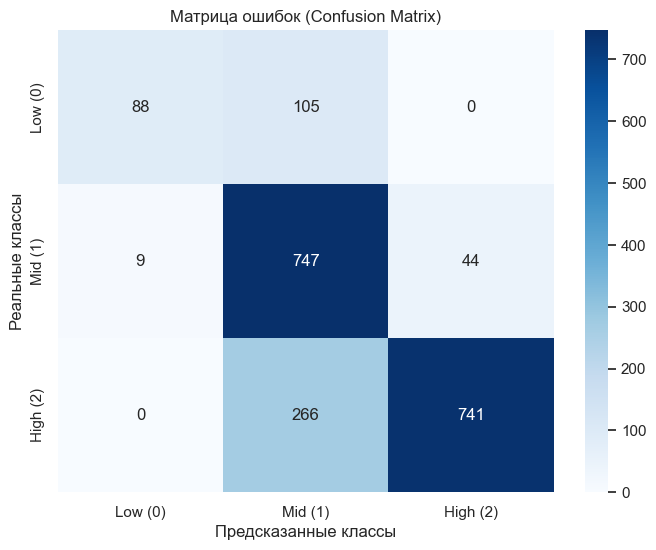

In [19]:
from sklearn.metrics import confusion_matrix      #1.19
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low (0)', 'Mid (1)', 'High (2)'],
            yticklabels=['Low (0)', 'Mid (1)', 'High (2)'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()

 Файл 'catalog_ml_predictions.xlsx' успешно сохранен!


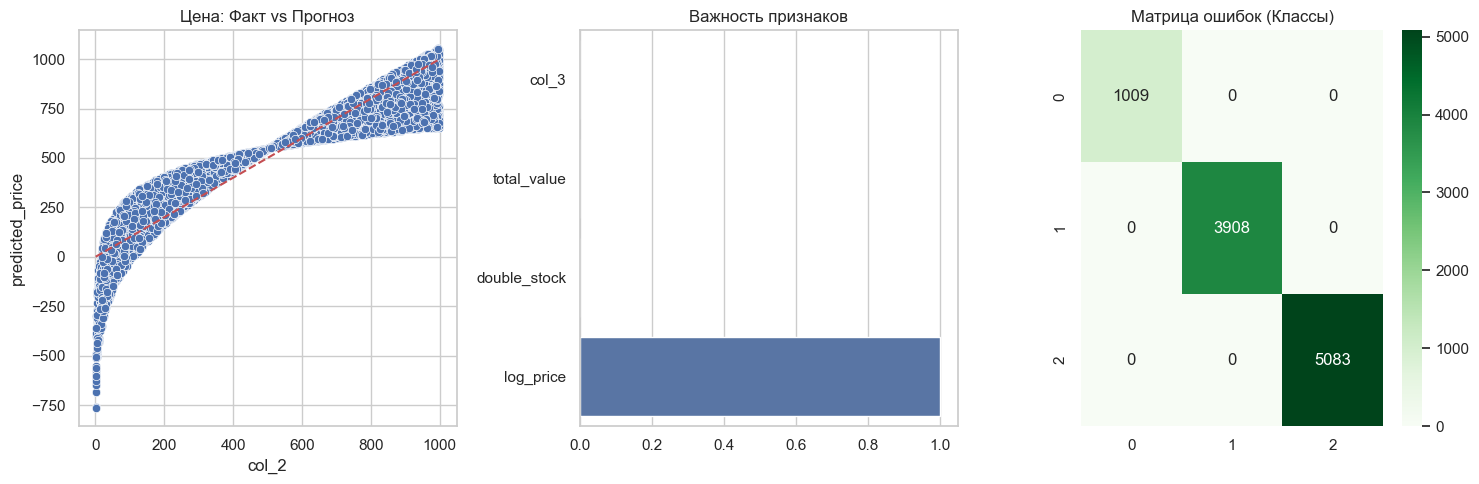

In [24]:
features = ['col_3', 'total_value', 'double_stock', 'log_price']
X = df[features]
y_reg = df['col_2']
y_clf = df['price_class']

model_reg = LinearRegression()
model_reg.fit(X, y_reg)
df['predicted_price'] = model_reg.predict(X)

model_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
model_clf.fit(X, y_clf)
df['predicted_class'] = model_clf.predict(X)

df.to_excel('catalog_ml_predictions.xlsx', index=False)
print(" Файл 'catalog_ml_predictions.xlsx' успешно сохранен!")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x=df['col_2'], y=df['predicted_price'])
plt.plot([df['col_2'].min(), df['col_2'].max()], [df['col_2'].min(), df['col_2'].max()], 'r--')
plt.title('Цена: Факт vs Прогноз')

plt.subplot(1, 3, 2)
importances = model_clf.feature_importances_
sns.barplot(x=importances, y=features)
plt.title('Важность признаков')

plt.subplot(1, 3, 3)
cm = confusion_matrix(df['price_class'], df['predicted_class'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Матрица ошибок (Классы)')

plt.tight_layout()
plt.show()